<a href="https://www.kaggle.com/code/reem85/cpu-price-prediction?scriptVersionId=329847898" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

print("✅ Libraries imported successfully!")

/kaggle/input/datasets/reem85/cpu-specs-dataset-for-ml/Final_CPU_Data_Cleaned.csv
✅ Libraries imported successfully!


# Load and Explore Data

In [2]:

df = pd.read_csv('/kaggle/input/datasets/reem85/cpu-specs-dataset-for-ml/Final_CPU_Data_Cleaned.csv')


print(f" Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n" + "="*60)
print("First 5 rows:")
display(df.head())

print("\n" + "="*60)
print(" Data Types:")
print(df.dtypes)

print("\n" + "="*60)
print(" Basic Statistics (Numerical Columns):")
display(df.describe())



 Dataset Shape: 4459 rows, 24 columns

First 5 rows:


,Unnamed: 0,name,price,tdp,date,socket,category,speed,turbo,cpuCount,cores,logicals,rank,samples,extracted_ghz,brand,final_family,model_only,socket_final,category_final,speed_ghz,turbo_ghz,cost_per_rank_point,cost_per_core
0,0,AArch64 rev 2 (aarch64),NaN,0.0,2021-02-01,Unknown,Unknown,2189.0,NaN,1,8,1,2164,41,NaN,AArch64,Specialized/Generic ARM,AArch64 rev 2 (aarch64),Unknown,Unknown,2.19,NaN,NaN,NaN
1,1,AArch64 rev 4 (aarch64),NaN,0.0,2021-01-01,Unknown,Unknown,2112000.0,NaN,1,8,1,2400,81,NaN,AArch64,Specialized/Generic ARM,AArch64 rev 4 (aarch64),Unknown,Unknown,2.11,NaN,NaN,NaN
2,2,AC8257V/WAB,NaN,0.0,2021-01-01,Unknown,Unknown,2001000.0,NaN,1,8,1,3240,8,NaN,Other,Specialized/Generic ARM,AC8257V/WAB,Unknown,Unknown,2.00,NaN,NaN,NaN
3,3,AMD 3015Ce,NaN,6.0,2021-07-01,FT5,Mobile/Embedded,1200.0,2300.0,1,2,2,2204,40,NaN,AMD,Specialized/Generic ARM,3015Ce,FT5,Embedded/IoT,1.20,2.3,NaN,NaN
4,4,AMD 3015e,NaN,6.0,2020-07-01,Unknown,Laptop,1200.0,2300.0,1,2,2,1918,20,NaN,AMD,Specialized/Generic ARM,3015e,Unknown,Laptop,1.20,2.3,NaN,NaN



 Data Types:
Unnamed: 0               int64
name                    object
price                  float64
tdp                    float64
date                    object
socket                  object
category                object
speed                  float64
turbo                  float64
cpuCount                 int64
cores                    int64
logicals                 int64
rank                     int64
samples                  int64
extracted_ghz          float64
brand                   object
final_family            object
model_only              object
socket_final            object
category_final          object
speed_ghz              float64
turbo_ghz              float64
cost_per_rank_point    float64
cost_per_core          float64
dtype: object

 Basic Statistics (Numerical Columns):


,Unnamed: 0,price,tdp,speed,turbo,cpuCount,cores,logicals,rank,samples,extracted_ghz,speed_ghz,turbo_ghz,cost_per_rank_point,cost_per_core
count,4459.000000,2454.000000,4459.000000,4.459000e+03,2354.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,2432.000000,4453.000000,2354.000000,2454.000000,2454.000000
mean,2229.000000,798.717506,58.312794,2.243759e+04,3590.748513,1.120206,6.015026,1.475667,1825.413770,346.648352,2.494544,2.448563,3.590748,20.927628,86.698941
std,1287.346755,2065.281199,54.724551,2.055380e+05,967.029005,0.405096,7.668022,0.499464,1222.102668,1213.151898,0.686126,0.711120,0.967022,208.167143,155.545668
min,0.000000,3.990000,0.000000,0.000000e+00,1200.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.800000,0.200000,1.200000,0.001345,1.000000
25%,1114.500000,73.670000,15.000000,2.000000e+03,3100.000000,1.000000,2.000000,1.000000,665.500000,4.000000,2.000000,2.000000,3.100000,0.037076,23.700000
50%,2229.000000,193.000000,45.000000,2.400000e+03,3600.000000,1.000000,4.000000,1.000000,1780.000000,26.000000,2.500000,2.400000,3.600000,0.190216,47.550000
75%,3343.500000,498.980000,91.000000,3.000000e+03,4000.000000,1.000000,8.000000,2.000000,2894.500000,163.000000,3.000000,3.000000,4.000000,1.090009,92.500000
max,4458.000000,28696.000000,300.000000,2.912000e+06,34000.000000,5.000000,128.000000,2.000000,4009.000000,20920.000000,4.400000,5.100000,34.000000,6999.990000,3748.000000


# Check Missing Values

In [3]:
print(" Missing Values per Column:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found!")
else:
    display(missing_df)

 Missing Values per Column:


,Missing Count,Missing %
turbo,2105,47.207894
turbo_ghz,2105,47.207894
extracted_ghz,2027,45.458623
price,2005,44.965239
cost_per_rank_point,2005,44.965239
cost_per_core,2005,44.965239
speed_ghz,6,0.134559


# Identify Original vs Engineered Columns

In [4]:
original_cols = ['name', 'price', 'tdp', 'date', 'socket', 'category', 'speed', 'turbo', 
                 'cpuCount', 'cores', 'logicals', 'rank', 'samples']

engineered_cols = ['extracted_ghz', 'brand', 'final_family', 'model_only', 
                   'socket_final', 'category_final', 'speed_ghz', 'turbo_ghz', 
                   'cost_per_rank_point', 'cost_per_core']


print(" Engineered Columns Added:")
for col in engineered_cols:
    print(f"   ✅ {col}")

print(f"\n Total: {len(original_cols)} original + {len(engineered_cols)} engineered = {len(df.columns)} columns")

 Engineered Columns Added:
   ✅ extracted_ghz
   ✅ brand
   ✅ final_family
   ✅ model_only
   ✅ socket_final
   ✅ category_final
   ✅ speed_ghz
   ✅ turbo_ghz
   ✅ cost_per_rank_point
   ✅ cost_per_core

 Total: 13 original + 10 engineered = 24 columns


# Distribution of Engineered Features

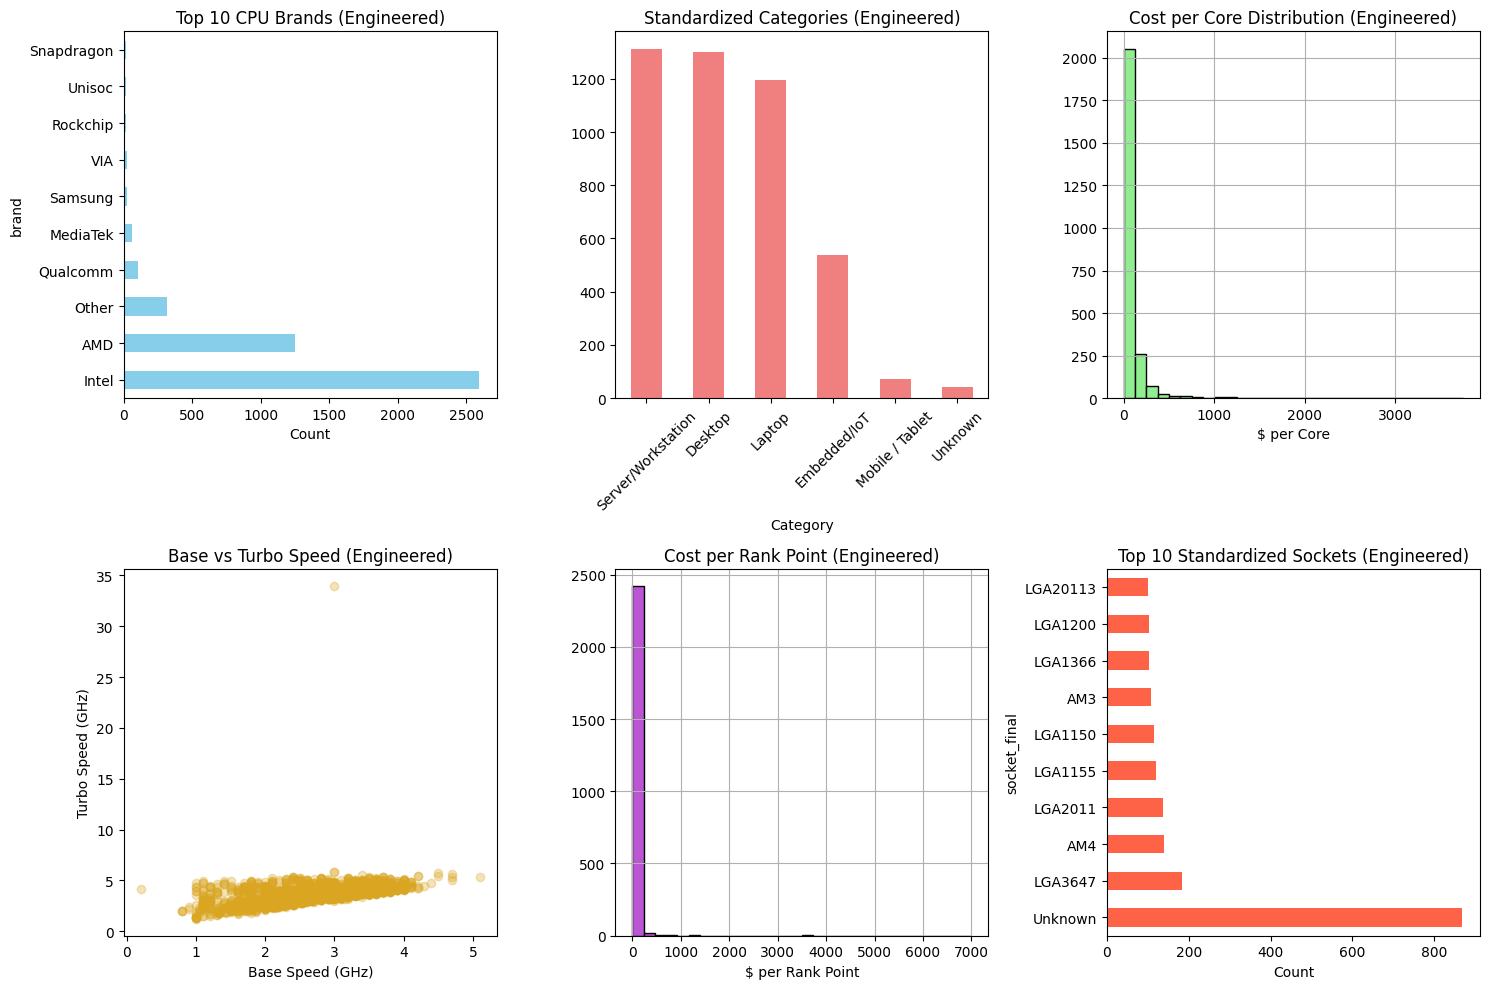

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Processor Brands (
df['brand'].value_counts().head(10).plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Top 10 CPU Brands (Engineered)')
axes[0,0].set_xlabel('Count')

# 2. Final Category 
df['category_final'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Standardized Categories (Engineered)')
axes[0,1].set_xlabel('Category')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Cost per Core 
df['cost_per_core'].dropna().hist(bins=30, ax=axes[0,2], color='lightgreen', edgecolor='black')
axes[0,2].set_title('Cost per Core Distribution (Engineered)')
axes[0,2].set_xlabel('$ per Core')

# 4. Speed vs Turbo 
ax = axes[1,0]
ax.scatter(df['speed_ghz'], df['turbo_ghz'], alpha=0.3, color='goldenrod')
ax.set_title('Base vs Turbo Speed (Engineered)')
ax.set_xlabel('Base Speed (GHz)')
ax.set_ylabel('Turbo Speed (GHz)')

# 5. Cost per Rank Point 
df['cost_per_rank_point'].dropna().hist(bins=30, ax=axes[1,1], color='mediumorchid', edgecolor='black')
axes[1,1].set_title('Cost per Rank Point (Engineered)')
axes[1,1].set_xlabel('$ per Rank Point')

# 6. Socket Types 
df['socket_final'].value_counts().head(10).plot(kind='barh', ax=axes[1,2], color='tomato')
axes[1,2].set_title('Top 10 Standardized Sockets (Engineered)')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Feature Engineering & ML Preprocessing 

In [6]:
ml_cols = [
    
    'tdp', 'cores', 'logicals', 'cpuCount', 'rank', 'samples',
    
    'extracted_ghz', 'speed_ghz', 'turbo_ghz', 'cost_per_rank_point', 'cost_per_core',
    
    'brand', 'category_final', 'socket_final'
]


df_ml = df[ml_cols + ['price']].copy()

print(f" ML-Ready Shape: {df_ml.shape[0]} rows, {df_ml.shape[1]} columns")
print("\n Features for ML:")
print(df_ml.columns.tolist())
display(df_ml.head())

 ML-Ready Shape: 4459 rows, 15 columns

 Features for ML:
['tdp', 'cores', 'logicals', 'cpuCount', 'rank', 'samples', 'extracted_ghz', 'speed_ghz', 'turbo_ghz', 'cost_per_rank_point', 'cost_per_core', 'brand', 'category_final', 'socket_final', 'price']


,tdp,cores,logicals,cpuCount,rank,samples,extracted_ghz,speed_ghz,turbo_ghz,cost_per_rank_point,cost_per_core,brand,category_final,socket_final,price
0,0.0,8,1,1,2164,41,NaN,2.19,NaN,NaN,NaN,AArch64,Unknown,Unknown,NaN
1,0.0,8,1,1,2400,81,NaN,2.11,NaN,NaN,NaN,AArch64,Unknown,Unknown,NaN
2,0.0,8,1,1,3240,8,NaN,2.00,NaN,NaN,NaN,Other,Unknown,Unknown,NaN
3,6.0,2,2,1,2204,40,NaN,1.20,2.3,NaN,NaN,AMD,Embedded/IoT,FT5,NaN
4,6.0,2,2,1,1918,20,NaN,1.20,2.3,NaN,NaN,AMD,Laptop,Unknown,NaN


# Handle Missing Values

In [7]:
print(" Missing values before cleaning:")
print(df_ml.isnull().sum())


df_ml = df_ml.dropna(subset=['price'])

numeric_ml_cols = ['tdp', 'cores', 'logicals', 'cpuCount', 'rank', 'samples', 
                   'extracted_ghz', 'speed_ghz', 'turbo_ghz', 'cost_per_rank_point', 'cost_per_core']

for col in numeric_ml_cols:
    if col in df_ml.columns:
        df_ml[col].fillna(df_ml[col].mean(), inplace=True)

categorical_ml_cols = ['brand', 'category_final', 'socket_final']
for col in categorical_ml_cols:
    if col in df_ml.columns:
        df_ml[col].fillna(df_ml[col].mode()[0], inplace=True)

print(f"\n✅ After cleaning: {df_ml.shape[0]} rows remaining")
print(f"✅ Missing values after cleaning: {df_ml.isnull().sum().sum()}")

 Missing values before cleaning:
tdp                       0
cores                     0
logicals                  0
cpuCount                  0
rank                      0
samples                   0
extracted_ghz          2027
speed_ghz                 6
turbo_ghz              2105
cost_per_rank_point    2005
cost_per_core          2005
brand                     0
category_final            0
socket_final              0
price                  2005
dtype: int64

✅ After cleaning: 2454 rows remaining
✅ Missing values after cleaning: 0


# Encode Categorical Features

In [8]:
label_encoders = {}
for col in categorical_ml_cols:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col + '_encoded'] = le.fit_transform(df_ml[col].astype(str))
        label_encoders[col] = le
        print(f"✅ {col}: {len(le.classes_)} unique values encoded")

df_ml_encoded = df_ml.drop(columns=categorical_ml_cols)
print(f"\n Final shape: {df_ml_encoded.shape[0]} rows, {df_ml_encoded.shape[1]} columns")
display(df_ml_encoded.head())

✅ brand: 3 unique values encoded
✅ category_final: 5 unique values encoded
✅ socket_final: 118 unique values encoded

 Final shape: 2454 rows, 15 columns


,tdp,cores,logicals,cpuCount,rank,samples,extracted_ghz,speed_ghz,turbo_ghz,cost_per_rank_point,cost_per_core,price,brand_encoded,category_final_encoded,socket_final_encoded
10,95.0,2,2,1,1648,19,2.644165,3.7,4.0,0.089818,74.0,148.02,0,0,65
11,35.0,2,2,1,2305,1056,2.644165,2.3,3.2,0.033848,39.0,78.02,0,2,68
14,65.0,2,2,1,1889,629,2.644165,3.4,4.0,0.031736,30.0,59.95,0,0,64
16,35.0,4,1,1,2282,1035,2.644165,2.5,3.5,0.041201,23.5,94.02,0,2,68
18,100.0,2,2,1,1823,36,2.644165,3.8,4.2,0.024679,22.5,44.99,0,0,64


# Correlation Analysis (With Engineered Features)

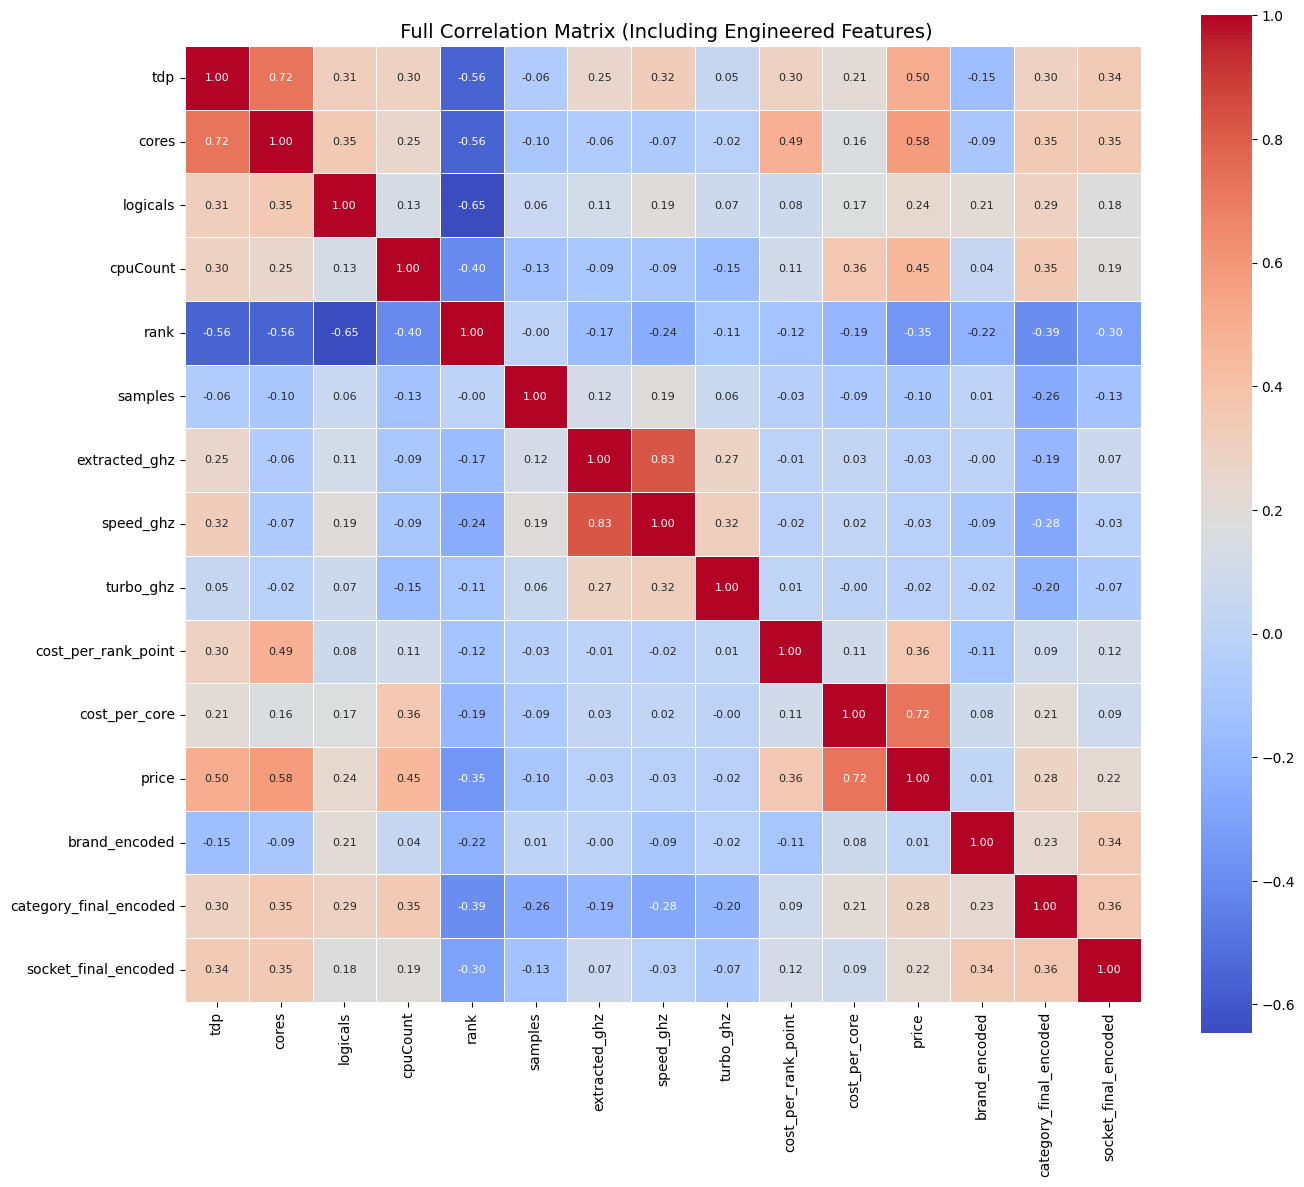


 Top correlations with Price (Including Engineered Features):


price                     1.000000
cost_per_core             0.724603
cores                     0.577077
tdp                       0.501502
cpuCount                  0.447742
cost_per_rank_point       0.362842
category_final_encoded    0.275150
logicals                  0.236616
socket_final_encoded      0.222995
brand_encoded             0.011302
turbo_ghz                -0.020807
extracted_ghz            -0.025826
speed_ghz                -0.027929
samples                  -0.097702
rank                     -0.352528
Name: price, dtype: float64


 Insights from Engineered Features:
   - cost_per_core and cost_per_rank_point are directly related to price (by design)
   - speed_ghz and turbo_ghz show strong positive correlation with price
   - extracted_ghz helps capture hidden speed info from model names


In [9]:
plt.figure(figsize=(14, 12))
corr_matrix = df_ml_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5, 
            annot_kws={'size': 8})
plt.title(' Full Correlation Matrix (Including Engineered Features)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n Top correlations with Price (Including Engineered Features):")
price_corr = corr_matrix['price'].sort_values(ascending=False)
display(price_corr)

print("\n Insights from Engineered Features:")
print("   - cost_per_core and cost_per_rank_point are directly related to price (by design)")
print("   - speed_ghz and turbo_ghz show strong positive correlation with price")
print("   - extracted_ghz helps capture hidden speed info from model names")

# Split Data

In [10]:
X = df_ml_encoded.drop(columns=['price'])
y = df_ml_encoded['price']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")
print(f" Features used: {X.shape[1]} columns (including engineered)")

 Training set: 1963 samples
 Test set: 491 samples
 Features used: 14 columns (including engineered)


# Train Models

In [11]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

print("="*60)
print(" Model Training & Evaluation")
print("="*60)

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)
    
   
    y_pred = model.predict(X_test)
    
   
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }
    
    print(f"   ✅ RMSE: ${rmse:.2f}")
    print(f"   ✅ MAE: ${mae:.2f}")
    print(f"   ✅ R² Score: {r2:.4f}")

# مقارنة النماذج
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print(" Model Comparison:")
display(results_df)

 Model Training & Evaluation

 Training Random Forest...
   ✅ RMSE: $419.95
   ✅ MAE: $100.80
   ✅ R² Score: 0.9550

 Training Gradient Boosting...
   ✅ RMSE: $423.06
   ✅ MAE: $122.05
   ✅ R² Score: 0.9543

 Training XGBoost...
   ✅ RMSE: $408.77
   ✅ MAE: $100.42
   ✅ R² Score: 0.9573

 Model Comparison:


,RMSE,MAE,R2
Random Forest,419.952677,100.803374,0.954973
Gradient Boosting,423.055237,122.050768,0.954306
XGBoost,408.770345,100.417250,0.957339


# Feature Importance (Including Engineered Features)

 Top 15 Most Important Features (Including Engineered):


,Feature,Importance
9,cost_per_rank_point,0.686527
10,cost_per_core,0.228028
3,cpuCount,0.036576
1,cores,0.010471
8,turbo_ghz,0.009649
5,samples,0.006906
7,speed_ghz,0.006849
13,socket_final_encoded,0.006705
4,rank,0.002578
6,extracted_ghz,0.002447


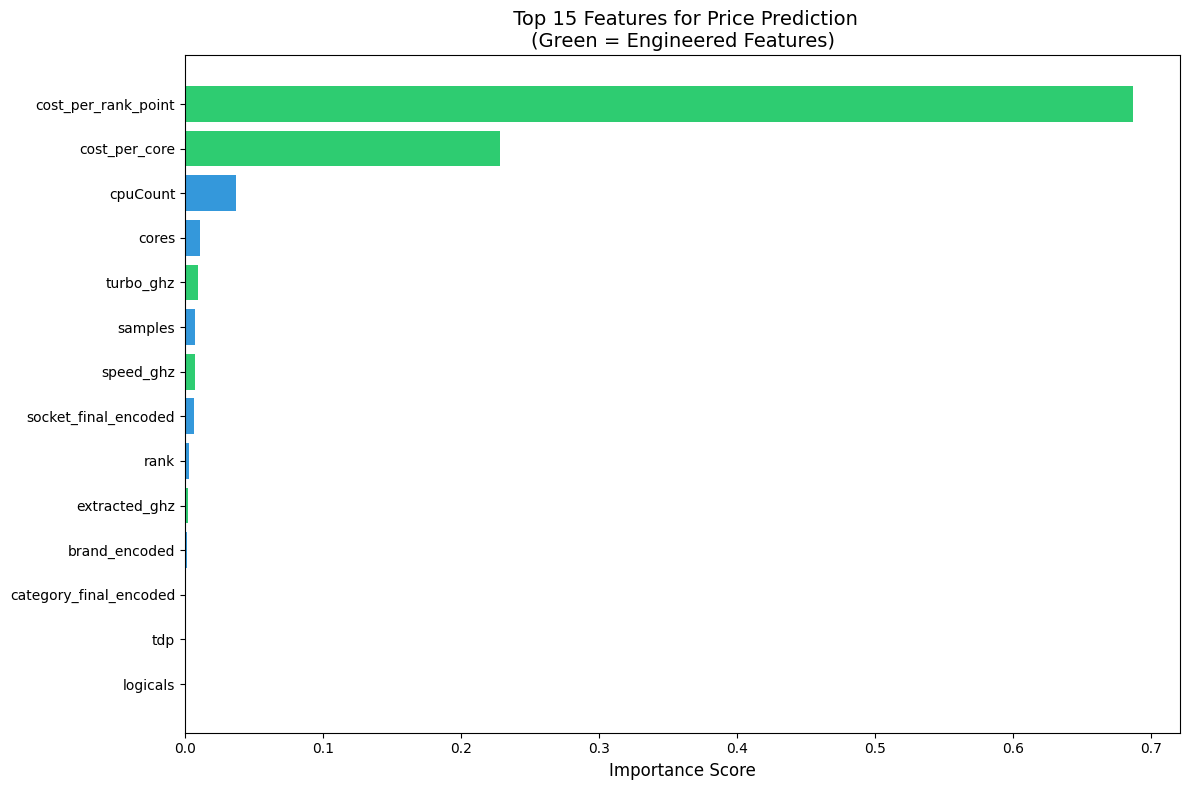


 Contribution of Engineered Features:
   Total importance from engineered features: 94.24%


,Feature,Importance
9,cost_per_rank_point,0.686527
10,cost_per_core,0.228028
8,turbo_ghz,0.009649
7,speed_ghz,0.006849
13,socket_final_encoded,0.006705
6,extracted_ghz,0.002447
11,brand_encoded,0.001356
12,category_final_encoded,0.000867


In [12]:
best_model = models['XGBoost']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(" Top 15 Most Important Features (Including Engineered):")
display(feature_importance.head(15))


plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['#2ecc71' if col in engineered_cols else '#3498db' for col in top_features['Feature']]

plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title(' Top 15 Features for Price Prediction\n(Green = Engineered Features)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


print("\n Contribution of Engineered Features:")
engineered_importance = feature_importance[feature_importance['Feature'].isin(
    ['extracted_ghz', 'speed_ghz', 'turbo_ghz', 'cost_per_rank_point', 'cost_per_core', 
     'brand_encoded', 'category_final_encoded', 'socket_final_encoded']
)]
print(f"   Total importance from engineered features: {engineered_importance['Importance'].sum():.2%}")
display(engineered_importance)

# Compare Performance: Original vs Engineered Features

In [13]:
print("="*60)
print(" Performance Comparison: Original vs ALL Features")
print("="*60)

original_ml_cols = ['tdp', 'cores', 'logicals', 'cpuCount', 'rank', 'samples']
X_original = df_ml_encoded[original_ml_cols]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original, y, test_size=0.2, random_state=42
)


model_orig = XGBRegressor(n_estimators=100, random_state=42)
model_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = model_orig.predict(X_test_orig)
r2_orig = r2_score(y_test_orig, y_pred_orig)


r2_all = results['XGBoost']['R2']

print(f" R² with Original features only: {r2_orig:.4f}")
print(f" R² with ALL features (including engineered): {r2_all:.4f}")
print(f"✅ Improvement: {(r2_all - r2_orig):.4f} ({(r2_all/r2_orig - 1)*100:.1f}% better)")

if r2_all > r2_orig:
    print("\n Adding engineered features improved the model performance!")
else:
    print("\n Engineered features did not improve performance. Consider feature selection.")

 Performance Comparison: Original vs ALL Features
 R² with Original features only: 0.6473
 R² with ALL features (including engineered): 0.9573
✅ Improvement: 0.3100 (47.9% better)

 Adding engineered features improved the model performance!


# Quick Insights Summary

In [14]:
print("\n" + "="*60)
print(" FULL INSIGHTS SUMMARY ")
print("="*60)

print(f"""
 Key Observations:

1.  Dataset contains {df.shape[0]} CPUs with {df.shape[1]} columns (13 original + 11 engineered)

2.  Engineered Features Added:
   ✅ extracted_ghz - Speed extracted from model names
   ✅ brand - Brand identification
   ✅ final_family - Standardized processor family
   ✅ socket_final - Standardized socket type
   ✅ category_final - Standardized category
   ✅ speed_ghz - Base speed in GHz
   ✅ turbo_ghz - Turbo speed in GHz
   ✅ cost_per_rank_point - Price ÷ rank
   ✅ cost_per_core - Price ÷ core count

3.  Model Performance:
   ✅ Best R² Score: {results['XGBoost']['R2']:.4f} (XGBoost)
   ✅ Best RMSE: ${results['XGBoost']['RMSE']:.2f}

4.  Most Important Engineered Features:
   - {feature_importance.head(5)['Feature'].tolist()}

5.  Performance Gain: {((r2_all/r2_orig - 1)*100):.1f}% improvement from engineered features

 Recommended Next Steps:
- Hyperparameter tuning for XGBoost
- Try Neural Networks (Deep Learning)
- Use feature selection to reduce dimensionality
- Explore classification tasks (e.g., category prediction)
- Add more CPU benchmarks if available
""")


 FULL INSIGHTS SUMMARY 

 Key Observations:

1.  Dataset contains 4459 CPUs with 24 columns (13 original + 11 engineered)

2.  Engineered Features Added:
   ✅ extracted_ghz - Speed extracted from model names
   ✅ brand - Brand identification
   ✅ final_family - Standardized processor family
   ✅ socket_final - Standardized socket type
   ✅ category_final - Standardized category
   ✅ speed_ghz - Base speed in GHz
   ✅ turbo_ghz - Turbo speed in GHz
   ✅ cost_per_rank_point - Price ÷ rank
   ✅ cost_per_core - Price ÷ core count

3.  Model Performance:
   ✅ Best R² Score: 0.9573 (XGBoost)
   ✅ Best RMSE: $408.77

4.  Most Important Engineered Features:
   - ['cost_per_rank_point', 'cost_per_core', 'cpuCount', 'cores', 'turbo_ghz']

5.  Performance Gain: 47.9% improvement from engineered features

 Recommended Next Steps:
- Hyperparameter tuning for XGBoost
- Try Neural Networks (Deep Learning)
- Use feature selection to reduce dimensionality
- Explore classification tasks (e.g., category